# Análise exploratória — Violência contra as mulheres no RS

Fonte: SIP/PROCERGS, consolidado em `src/load_data.py` a partir de `data/raw/*.xlsx`.

Duas tabelas de entrada, em `outputs/tables/`:

- **`violencia_mensal_municipio.csv`** — 2018-2026, por município e mês (`municipio, ano, mes, tipo_crime, casos`).
- **`violencia_anual_municipio.csv`** — 2012-2026, por município e ano (`municipio, ano, tipo_crime, casos_total`).

**2026 é um ano parcial** (dados só até por volta de junho/2026) — isso é levado em conta e sinalizado visualmente em cada análise que soma por ano.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from pathlib import Path

TABLES_DIR = Path("../outputs/tables")
FIGURES_DIR = Path("../outputs/figures")
REPORTS_DIR = Path("../outputs/reports")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

mensal = pd.read_csv(TABLES_DIR / "violencia_mensal_municipio.csv")
anual = pd.read_csv(TABLES_DIR / "violencia_anual_municipio.csv")

# Ordem fixa das categorias e uma cor por categoria, reaproveitadas em
# todos os gráficos do notebook (nunca recicladas por ranking/filtro).
CRIME_ORDER = [
    "Ameaça",
    "Estupro",
    "Feminicídio Consumado",
    "Feminicídio Tentado",
    "Lesão Corporal",
]
CRIME_COLORS = {
    "Ameaça": "#2a78d6",
    "Estupro": "#1baf7a",
    "Feminicídio Consumado": "#eda100",
    "Feminicídio Tentado": "#008300",
    "Lesão Corporal": "#4a3aa7",
}
MUTED = "#898781"
GRID = "#e1e0d9"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
ANO_PARCIAL = 2026  # 2026 só tem dados até por volta de junho


def style_ax(ax):
    """Estilo padrão do notebook: sem moldura, grade horizontal sutil."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK_SECONDARY, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=1)
    ax.set_axisbelow(True)


def fmt_milhar(x, _pos=None):
    """Formata número com separador de milhar no padrão brasileiro (1.234)."""
    return f"{x:,.0f}".replace(",", ".")


mensal.head()

,municipio,ano,mes,tipo_crime,casos
0,ACEGUA,2018,1,Feminicídio Tentado,0
1,ACEGUA,2018,2,Feminicídio Tentado,0
2,ACEGUA,2018,3,Feminicídio Tentado,0
3,ACEGUA,2018,4,Feminicídio Tentado,0
4,ACEGUA,2018,5,Feminicídio Tentado,0


## 1. Estatísticas descritivas gerais

Total de casos por tipo de crime e participação percentual de cada categoria no total, somando todo o período coberto pela tabela anual (2012-2026 — lembrando que 2026 é parcial, então sua contribuição para os totais abaixo está levemente subestimada).

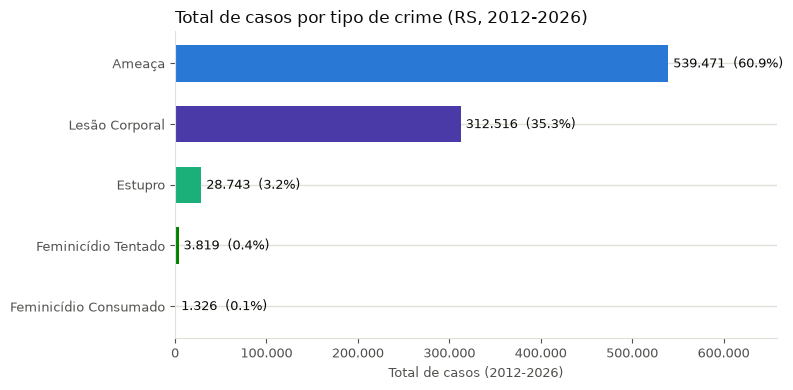

,casos_total,participacao_%
tipo_crime,,
Ameaça,539471,60.90
Lesão Corporal,312516,35.28
Estupro,28743,3.24
Feminicídio Tentado,3819,0.43
Feminicídio Consumado,1326,0.15


In [2]:
totais = (
    anual.groupby("tipo_crime")["casos_total"]
    .sum()
    .reindex(CRIME_ORDER)
    .sort_values(ascending=True)
)
pct = totais / totais.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    totais.index,
    totais.values,
    color=[CRIME_COLORS[c] for c in totais.index],
    height=0.6,
)
for bar, total, p in zip(bars, totais.values, pct.values):
    ax.text(
        bar.get_width() + totais.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{fmt_milhar(total)}  ({p:.1f}%)",
        va="center",
        fontsize=9,
        color=INK_PRIMARY,
    )
ax.set_xlim(0, totais.max() * 1.22)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_milhar))
style_ax(ax)
ax.set_xlabel("Total de casos (2012-2026)", color=INK_SECONDARY, fontsize=9)
ax.set_title(
    "Total de casos por tipo de crime (RS, 2012-2026)", loc="left", color=INK_PRIMARY
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exploratoria_totais_por_tipo.png", dpi=150, bbox_inches="tight")
plt.show()

resultado_totais = pd.DataFrame({"casos_total": totais, "participacao_%": pct.round(2)}).sort_values(
    "casos_total", ascending=False
)
resultado_totais.to_csv(REPORTS_DIR / "exploratoria_totais_por_tipo.csv")
resultado_totais

## 2. Série temporal anual por tipo de crime (2012-2026)

Total do estado (soma de todos os municípios) por ano e tipo de crime.

As 5 categorias têm ordens de grandeza muito diferentes (Ameaça é ~400x maior que Feminicídio Consumado) — por isso o eixo Y usa **escala logarítmica**, mantendo um único eixo (nunca dois eixos Y na mesma figura, o que inventaria uma correlação falsa entre escalas arbitrárias).

**2026 é parcial** (jan-jun): o segmento final de cada linha aparece tracejado, com um marcador vazado no ponto de 2026, em vez de um ponto cheio igual aos demais anos.

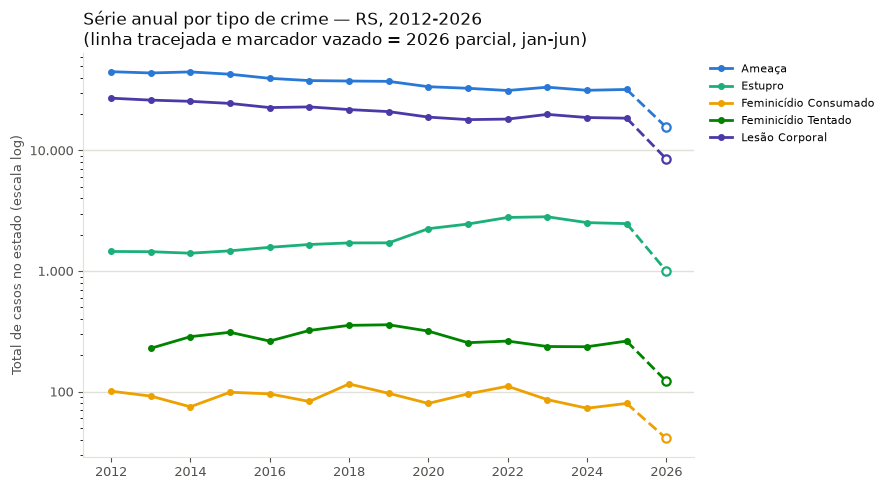

In [3]:
estado_ano_tipo = anual.groupby(["ano", "tipo_crime"])["casos_total"].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for tipo in CRIME_ORDER:
    serie = (
        estado_ano_tipo[estado_ano_tipo.tipo_crime == tipo]
        .set_index("ano")["casos_total"]
        .sort_index()
    )
    cor = CRIME_COLORS[tipo]

    completos = serie[serie.index < ANO_PARCIAL]
    ax.plot(
        completos.index,
        completos.values,
        color=cor,
        linewidth=2,
        marker="o",
        markersize=4,
        label=tipo,
    )

    if ANO_PARCIAL in serie.index:
        ultimo_ano_completo = completos.index.max()
        segmento = serie.loc[[ultimo_ano_completo, ANO_PARCIAL]]
        ax.plot(segmento.index, segmento.values, color=cor, linewidth=2, linestyle="--")
        ax.scatter(
            [ANO_PARCIAL],
            [serie.loc[ANO_PARCIAL]],
            facecolors="white",
            edgecolors=cor,
            linewidths=1.6,
            s=36,
            zorder=5,
        )

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_milhar))
ax.set_ylabel("Total de casos no estado (escala log)", color=INK_SECONDARY, fontsize=9)
ax.set_title(
    "Série anual por tipo de crime — RS, 2012-2026\n"
    "(linha tracejada e marcador vazado = 2026 parcial, jan-jun)",
    loc="left",
    color=INK_PRIMARY,
)
style_ax(ax)
ax.xaxis.grid(False)
ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exploratoria_serie_anual_tipo.png", dpi=150, bbox_inches="tight")
plt.show()

estado_ano_tipo.to_csv(REPORTS_DIR / "exploratoria_serie_anual_tipo.csv", index=False)

## 3. Ranking dos 15 municípios com maiores números absolutos (por tipo de crime)

Soma de todo o período (2012-2026) por município, um ranking separado para cada tipo de crime.

Cada categoria vai num subplot com sua própria cor fixa e sua própria escala de eixo X — assim como na Seção 2, colocar as 5 categorias num único eixo compartilhado esconderia as menores (Feminicídio Consumado e Tentado têm totais ~1000x menores que Ameaça).

A linha "NÃO INFORMADO" (casos de 2018 sem município identificado) é excluída do ranking — não é um município real.

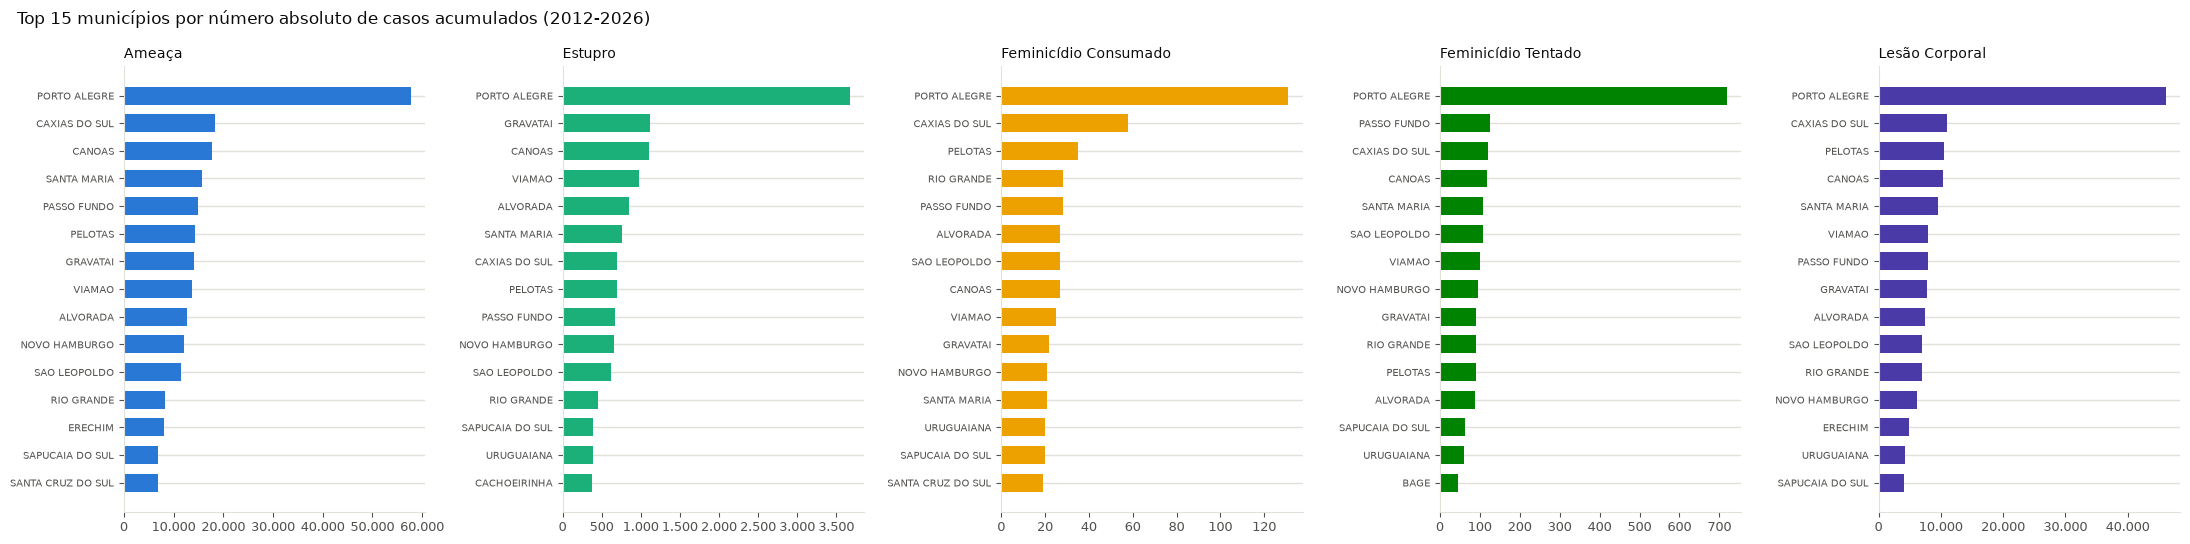

In [4]:
municipio_tipo = (
    anual[anual.municipio != "NÃO INFORMADO"]
    .groupby(["tipo_crime", "municipio"])["casos_total"]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 5, figsize=(22, 5.5))
for ax, tipo in zip(axes, CRIME_ORDER):
    top15 = (
        municipio_tipo[municipio_tipo.tipo_crime == tipo]
        .nlargest(15, "casos_total")
        .sort_values("casos_total")
    )
    ax.barh(top15.municipio, top15.casos_total, color=CRIME_COLORS[tipo], height=0.65)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_milhar))
    ax.set_title(tipo, loc="left", fontsize=10, color=INK_PRIMARY)
    style_ax(ax)
    ax.tick_params(axis="y", labelsize=7.5)

fig.suptitle(
    "Top 15 municípios por número absoluto de casos acumulados (2012-2026)",
    x=0.01,
    ha="left",
    color=INK_PRIMARY,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exploratoria_ranking_top15_absoluto.png", dpi=150, bbox_inches="tight")
plt.show()

ranking_top15_absoluto = pd.concat(
    [
        municipio_tipo[municipio_tipo.tipo_crime == tipo].nlargest(15, "casos_total")
        for tipo in CRIME_ORDER
    ],
    ignore_index=True,
)
ranking_top15_absoluto.to_csv(REPORTS_DIR / "exploratoria_ranking_top15_absoluto.csv", index=False)

## 4. Análise de concentração

Que % dos casos do estado (todos os tipos de crime, 2012-2026) se concentra nos 10 maiores municípios — com e sem a capital.

Porto Alegre destacada em vermelho no primeiro gráfico (emphasis: destaca uma barra, cinza no resto, em vez de uma cor por município — a identidade que importa aqui é "capital vs. resto", não os municípios individualmente). O segundo gráfico refaz o Top 10 excluindo Porto Alegre, para mostrar a concentração no "resto do estado" separadamente.

Top 10 municípios concentram 37.2% dos casos do estado (2012-2026, todos os tipos).
Porto Alegre sozinha representa 12.2% do total do estado.
Excluindo Porto Alegre, o Top 10 do restante do estado concentra 30.9% do total sem a capital.


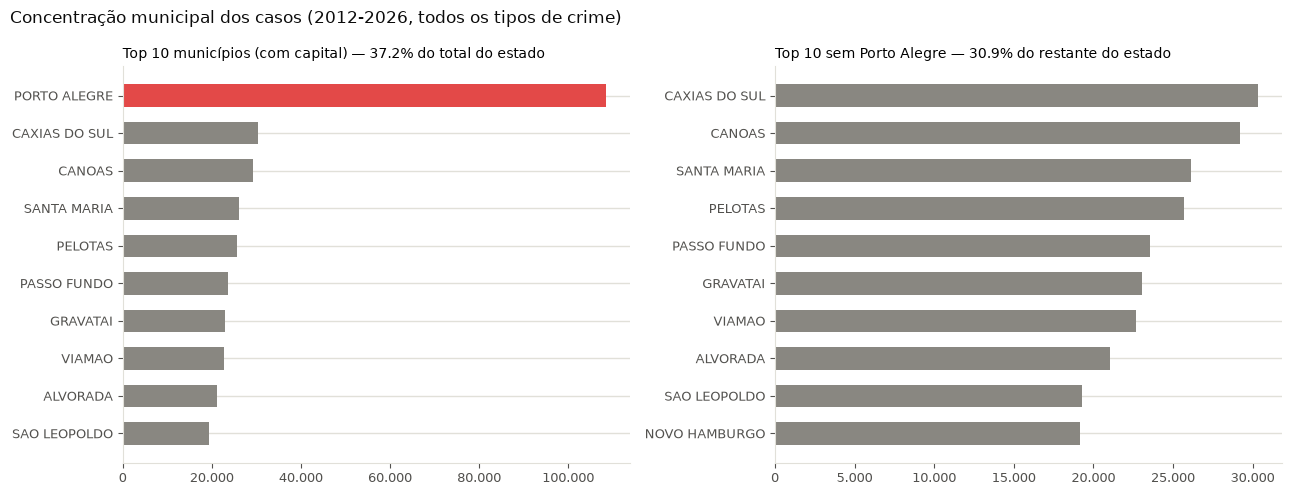

In [5]:
total_por_municipio = (
    anual[anual.municipio != "NÃO INFORMADO"]
    .groupby("municipio")["casos_total"]
    .sum()
    .sort_values(ascending=False)
)

top10 = total_por_municipio.head(10)
pct_top10 = top10.sum() / total_por_municipio.sum() * 100
pct_poa = total_por_municipio["PORTO ALEGRE"] / total_por_municipio.sum() * 100

resto_do_estado = total_por_municipio.drop("PORTO ALEGRE")
top10_sem_poa = resto_do_estado.head(10)
pct_top10_sem_poa = top10_sem_poa.sum() / resto_do_estado.sum() * 100

print(f"Top 10 municípios concentram {pct_top10:.1f}% dos casos do estado (2012-2026, todos os tipos).")
print(f"Porto Alegre sozinha representa {pct_poa:.1f}% do total do estado.")
print(
    f"Excluindo Porto Alegre, o Top 10 do restante do estado concentra "
    f"{pct_top10_sem_poa:.1f}% do total sem a capital."
)

resumo_concentracao = pd.DataFrame(
    {
        "métrica": ["pct_top10_com_poa", "pct_porto_alegre", "pct_top10_sem_poa"],
        "valor_pct": [pct_top10, pct_poa, pct_top10_sem_poa],
    }
)
resumo_concentracao.to_csv(REPORTS_DIR / "exploratoria_concentracao_resumo.csv", index=False)
top10.rename("casos_total").to_csv(REPORTS_DIR / "exploratoria_concentracao_top10_com_poa.csv")
top10_sem_poa.rename("casos_total").to_csv(
    REPORTS_DIR / "exploratoria_concentracao_top10_sem_poa.csv"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top10_plot = top10.sort_values()
cores = ["#e34948" if m == "PORTO ALEGRE" else MUTED for m in top10_plot.index]
axes[0].barh(top10_plot.index, top10_plot.values, color=cores, height=0.6)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_milhar))
axes[0].set_title(
    f"Top 10 municípios (com capital) — {pct_top10:.1f}% do total do estado",
    loc="left",
    fontsize=10,
)
style_ax(axes[0])

top10_sem_poa_plot = top10_sem_poa.sort_values()
axes[1].barh(top10_sem_poa_plot.index, top10_sem_poa_plot.values, color=MUTED, height=0.6)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_milhar))
axes[1].set_title(
    f"Top 10 sem Porto Alegre — {pct_top10_sem_poa:.1f}% do restante do estado",
    loc="left",
    fontsize=10,
)
style_ax(axes[1])

fig.suptitle(
    "Concentração municipal dos casos (2012-2026, todos os tipos de crime)",
    x=0.01,
    ha="left",
    color=INK_PRIMARY,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exploratoria_concentracao_top10.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Taxa por 100 mil habitantes

Até aqui todas as análises foram em número absoluto de casos — o que mistura "mais violência" com "mais gente morando ali". Esta seção usa `violencia_anual_municipio_taxa.csv` (`src/load_data.py` + `src/fetch_populacao.py`) para normalizar pela população.

**Limitação de metodologia, já documentada em `load_data.py`:** a taxa aqui usa população **total** (todos os gêneros), não só população feminina. O IBGE só quebra população por sexo no ano de Censo — as estimativas intercensitárias (que cobrem os demais anos) só têm população total. A DEE-RS tem população feminina por município, mas apenas até 2021 (descontinuada após as enchentes de maio/2024). A planilha original da SSP calculava "mulheres vítimas por 10.000 habitantes **mulheres**" — a taxa abaixo não é diretamente comparável a essa métrica original, é uma aproximação com população total.

**5.1 — Ranking por taxa** (não por número absoluto): refeito com um filtro de população mínima (5.000+ habitantes em 2025) para não deixar 1 caso isolado num município minúsculo gerar uma taxa gigante sem significado estatístico.

O primeiro gráfico já é a **média de todo o período disponível (2012-2025, 14 anos)** — não um ano isolado, e não "soma dos casos dividida por uma única população" (a população de cada município muda ano a ano, então a média das taxas anuais é mais correta do que uma taxa acumulada ingênua). Mesmo assim, 14 anos ainda pode esconder oscilação: um município pequeno com poucos casos por ano pode ter uma média puxada por 1-2 anos atípicos. Por isso o segundo gráfico repete o ranking usando só os **últimos 5 anos (2021-2025)**, para checar se os mesmos municípios aparecem nos dois recortes (hotspot consistente) ou se a lista muda bastante (mais ruído estatístico que padrão real).

Municípios elegíveis (população 2025 >= 5.000): 266 de 497


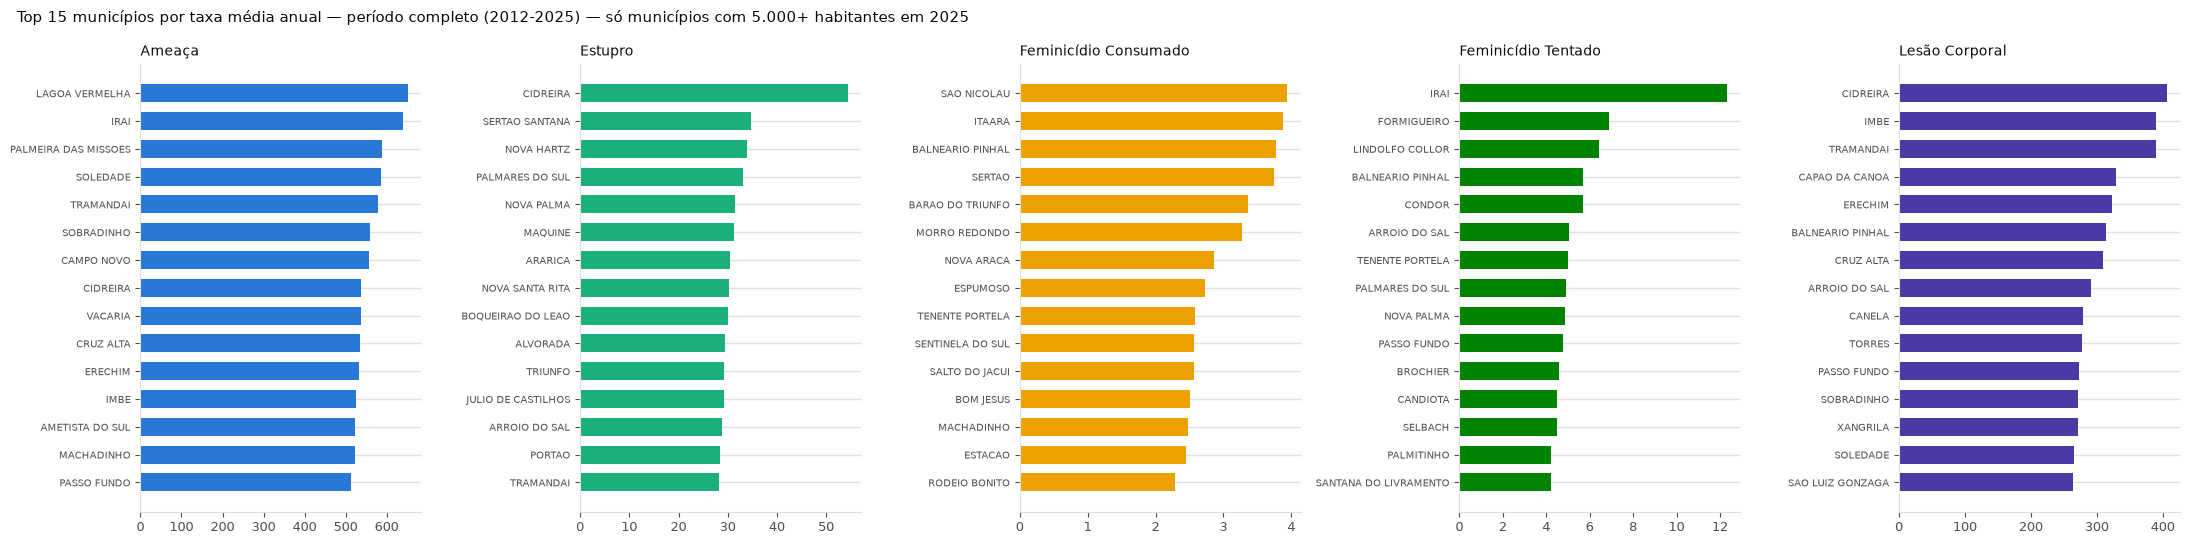

In [6]:
taxa = pd.read_csv(TABLES_DIR / "violencia_anual_municipio_taxa.csv")

POP_MINIMA = 5000
ANO_RECENTE = 2025

pop_recente = (
    taxa[taxa.ano == ANO_RECENTE].drop_duplicates("municipio").set_index("municipio")["populacao"]
)
elegiveis = pop_recente[pop_recente >= POP_MINIMA].index
print(
    f"Municípios elegíveis (população {ANO_RECENTE} >= {fmt_milhar(POP_MINIMA)}): "
    f"{len(elegiveis)} de {len(pop_recente)}"
)

base_elegivel = taxa[(taxa.municipio != "NÃO INFORMADO") & (taxa.municipio.isin(elegiveis))]
taxa_media = (
    base_elegivel.groupby(["tipo_crime", "municipio"])["taxa_por_100mil_hab"].mean().reset_index()
)

fig, axes = plt.subplots(1, 5, figsize=(22, 5.5))
for ax, tipo in zip(axes, CRIME_ORDER):
    top15 = (
        taxa_media[taxa_media.tipo_crime == tipo]
        .nlargest(15, "taxa_por_100mil_hab")
        .sort_values("taxa_por_100mil_hab")
    )
    ax.barh(top15.municipio, top15.taxa_por_100mil_hab, color=CRIME_COLORS[tipo], height=0.65)
    ax.set_title(tipo, loc="left", fontsize=10, color=INK_PRIMARY)
    style_ax(ax)
    ax.tick_params(axis="y", labelsize=7.5)

fig.suptitle(
    f"Top 15 municípios por taxa média anual — período completo (2012-2025) "
    f"— só municípios com {fmt_milhar(POP_MINIMA)}+ habitantes em {ANO_RECENTE}",
    x=0.01,
    ha="left",
    color=INK_PRIMARY,
    fontsize=10.5,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exploratoria_ranking_taxa_2012_2025.png", dpi=150, bbox_inches="tight")
plt.show()

ranking_taxa_2012_2025 = pd.concat(
    [
        taxa_media[taxa_media.tipo_crime == tipo].nlargest(15, "taxa_por_100mil_hab")
        for tipo in CRIME_ORDER
    ],
    ignore_index=True,
)
ranking_taxa_2012_2025.to_csv(REPORTS_DIR / "exploratoria_ranking_taxa_2012_2025.csv", index=False)

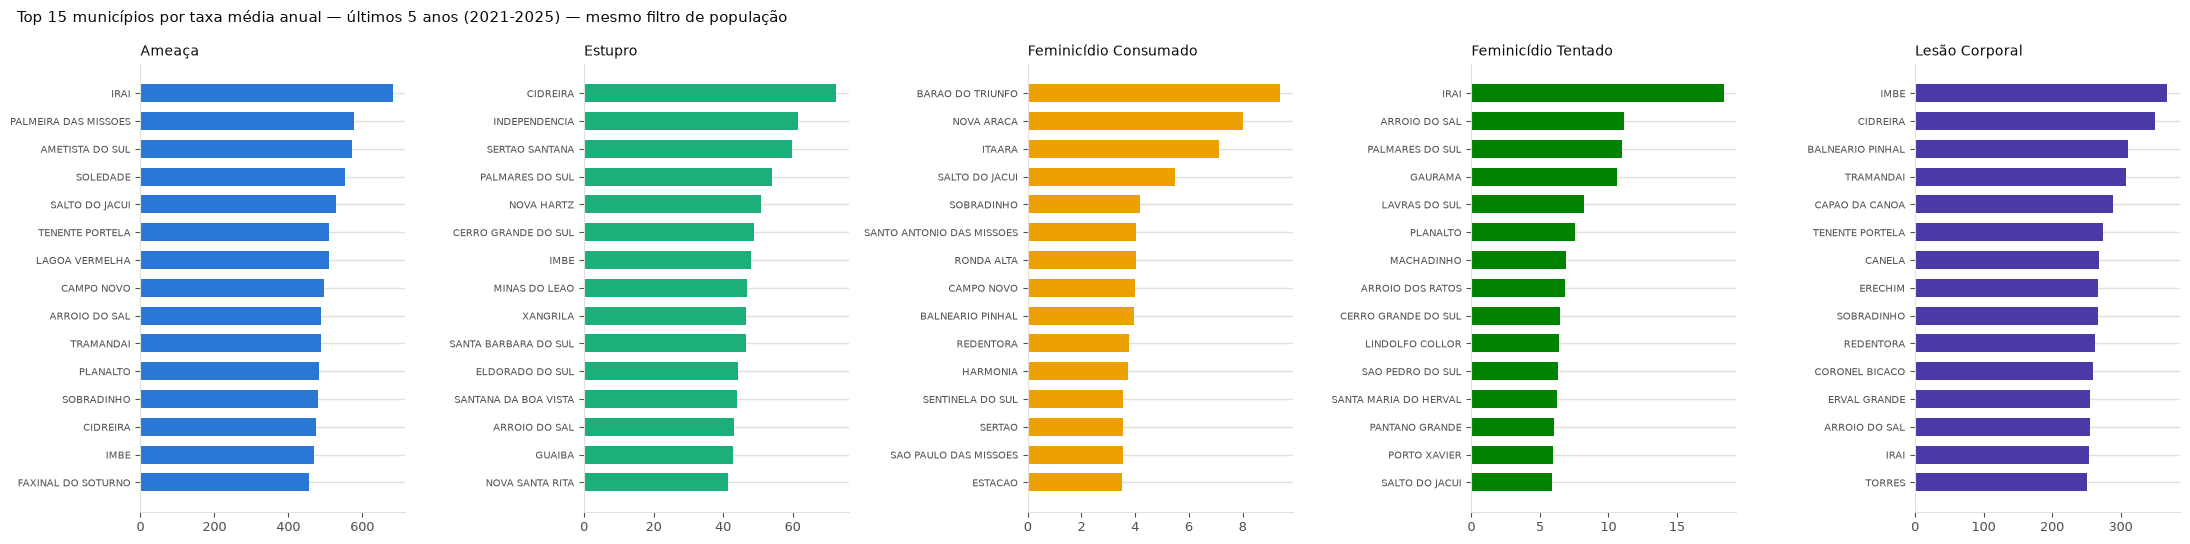

Sobreposição entre o Top 15 do período completo e o Top 15 recente, por tipo de crime:
  Ameaça: 10/15 municípios em comum
  Estupro: 6/15 municípios em comum
  Feminicídio Consumado: 8/15 municípios em comum
  Feminicídio Tentado: 4/15 municípios em comum
  Lesão Corporal: 10/15 municípios em comum


In [7]:
JANELA_RECENTE = 5  # últimos N anos, para checar consistência do ranking acima
# ANO_RECENTE (2025) é o último ano com população -- não usar taxa.ano.max()
# aqui, que é 2026: a coluna "ano" inclui 2026 mesmo sem dado de população.
ano_min_recente = ANO_RECENTE - JANELA_RECENTE + 1  # 2025 - 5 + 1 = 2021

taxa_media_recente = (
    base_elegivel[base_elegivel.ano >= ano_min_recente]
    .groupby(["tipo_crime", "municipio"])["taxa_por_100mil_hab"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 5, figsize=(22, 5.5))
for ax, tipo in zip(axes, CRIME_ORDER):
    top15 = (
        taxa_media_recente[taxa_media_recente.tipo_crime == tipo]
        .nlargest(15, "taxa_por_100mil_hab")
        .sort_values("taxa_por_100mil_hab")
    )
    ax.barh(top15.municipio, top15.taxa_por_100mil_hab, color=CRIME_COLORS[tipo], height=0.65)
    ax.set_title(tipo, loc="left", fontsize=10, color=INK_PRIMARY)
    style_ax(ax)
    ax.tick_params(axis="y", labelsize=7.5)

fig.suptitle(
    f"Top 15 municípios por taxa média anual — últimos {JANELA_RECENTE} anos "
    f"({ano_min_recente}-{ANO_RECENTE}) — mesmo filtro de população",
    x=0.01,
    ha="left",
    color=INK_PRIMARY,
    fontsize=10.5,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exploratoria_ranking_taxa_2021_2025.png", dpi=150, bbox_inches="tight")
plt.show()

ranking_taxa_2021_2025 = pd.concat(
    [
        taxa_media_recente[taxa_media_recente.tipo_crime == tipo].nlargest(
            15, "taxa_por_100mil_hab"
        )
        for tipo in CRIME_ORDER
    ],
    ignore_index=True,
)
ranking_taxa_2021_2025.to_csv(REPORTS_DIR / "exploratoria_ranking_taxa_2021_2025.csv", index=False)

print("Sobreposição entre o Top 15 do período completo e o Top 15 recente, por tipo de crime:")
overlap_rows = []
for tipo in CRIME_ORDER:
    top_completo = set(
        taxa_media[taxa_media.tipo_crime == tipo].nlargest(15, "taxa_por_100mil_hab").municipio
    )
    top_recente = set(
        taxa_media_recente[taxa_media_recente.tipo_crime == tipo]
        .nlargest(15, "taxa_por_100mil_hab")
        .municipio
    )
    overlap = len(top_completo & top_recente)
    print(f"  {tipo}: {overlap}/15 municípios em comum")
    overlap_rows.append({"tipo_crime": tipo, "municipios_em_comum": overlap, "de": 15})

pd.DataFrame(overlap_rows).to_csv(REPORTS_DIR / "exploratoria_overlap_ranking_taxa.csv", index=False)

**5.2 — Porto Alegre vs. média do estado (taxa):** pergunta diferente da concentração absoluta da Seção 4. Lá, Porto Alegre domina o ranking simplesmente por ser a maior cidade do estado. Aqui, a pergunta é se a capital tem uma taxa (por habitante) acima ou abaixo da média estadual — soma de todos os tipos de crime, por ano.

**Detalhe que muda a interpretação:** a "taxa do estado" abaixo é calculada **excluindo Porto Alegre** do numerador e do denominador — ou seja, é a taxa do "resto do estado", não uma média estadual que já inclui a própria Porto Alegre. Comparar a capital contra uma média da qual ela mesma faz parte amorteceria artificialmente a diferença (~13% da população do estado é de Porto Alegre). Excluí-la deixa a comparação "capital vs. resto" mais correta, no mesmo espírito do "Top 10 sem Porto Alegre" da Seção 4.

Porto Alegre / resto do estado (sem PoA), por ano:
ano
2012    0.97
2013    0.96
2014    0.92
2015    0.91
2016    0.89
2017    0.96
2018    1.05
2019    1.00
2020    0.93
2021    0.86
2022    0.89
2023    0.89
2024    0.97
2025    0.94
dtype: float64

Média da razão no período: 0.94
-> Porto Alegre fica, na média, ABAIXO da taxa do resto do estado (a concentração absoluta da Seção 4 é sobretudo efeito de tamanho populacional, não de uma taxa por habitante desproporcionalmente mais alta na capital).


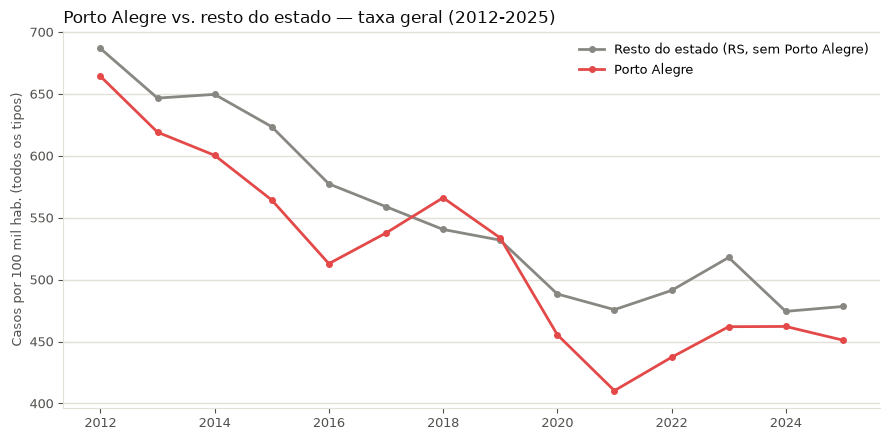

In [8]:
total_municipio_ano = (
    anual[anual.municipio != "NÃO INFORMADO"]
    .groupby(["municipio", "ano"])["casos_total"]
    .sum()
    .reset_index()
)
populacao = pd.read_csv(TABLES_DIR / "populacao_municipio_rs.csv")
total_municipio_ano = total_municipio_ano.merge(populacao, on=["municipio", "ano"], how="inner")

poa = total_municipio_ano[total_municipio_ano.municipio == "PORTO ALEGRE"].set_index("ano")
resto_do_estado = total_municipio_ano[total_municipio_ano.municipio != "PORTO ALEGRE"]

# "Resto do estado" exclui Porto Alegre do numerador E do denominador —
# comparar a capital com uma média que já a inclui amorteceria a diferença.
taxa_resto = resto_do_estado.groupby("ano").apply(
    lambda g: g.casos_total.sum() / g.populacao.sum() * 100_000, include_groups=False
)
taxa_poa = poa.casos_total / poa.populacao * 100_000

razao = (taxa_poa / taxa_resto).round(2)
print(f"Porto Alegre / resto do estado (sem PoA), por ano:\n{razao}\n")
print(f"Média da razão no período: {razao.mean():.2f}")
print(
    "-> Porto Alegre fica, na média, "
    f"{'ACIMA' if razao.mean() > 1 else 'ABAIXO'} da taxa do resto do estado "
    "(a concentração absoluta da Seção 4 é sobretudo efeito de tamanho populacional, "
    "não de uma taxa por habitante desproporcionalmente mais alta na capital)."
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    taxa_resto.index, taxa_resto.values, color=MUTED, linewidth=2,
    marker="o", markersize=4, label="Resto do estado (RS, sem Porto Alegre)",
)
ax.plot(
    taxa_poa.index, taxa_poa.values, color="#e34948", linewidth=2,
    marker="o", markersize=4, label="Porto Alegre",
)
style_ax(ax)
ax.xaxis.grid(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_milhar))
ax.set_ylabel("Casos por 100 mil hab. (todos os tipos)", color=INK_SECONDARY, fontsize=9)
ax.set_title(
    "Porto Alegre vs. resto do estado — taxa geral (2012-2025)", loc="left", color=INK_PRIMARY
)
ax.legend(frameon=False, fontsize=9, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exploratoria_poa_vs_estado_taxa.png", dpi=150, bbox_inches="tight")
plt.show()

resultado_poa_vs_estado = pd.DataFrame(
    {
        "ano": taxa_resto.index,
        "taxa_resto_estado": taxa_resto.values,
        "taxa_porto_alegre": taxa_poa.reindex(taxa_resto.index).values,
        "razao_poa_sobre_resto": razao.reindex(taxa_resto.index).values,
    }
)
resultado_poa_vs_estado.to_csv(REPORTS_DIR / "exploratoria_poa_vs_estado_taxa.csv", index=False)